In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Data/tech_job_market_2019_2026 (1).csv")

In [5]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,11/12/2023 0:00,11/20/2023,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,6/29/2025 0:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,1/24/2026 0:00,2/8/2026,Filled,36.0,4.0,1.0,1.0,238800,274700,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,12/9/2020 0:00,12/21/2020,Filled,300.0,1.0,6.0,5.0,96300,104000,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,7/19/2025 0:00,9/15/2025,Filled,43.0,3.0,1.0,1.0,"$186,800",245400,1


In [9]:
df.shape

(115000, 28)

There are 115000 rows and 28 columns


In [10]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


There are 21 string type cols, 3 integer type cols, 4 float type cols


In [13]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [14]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [6]:
df.isnull().sum().sum()

np.int64(87962)

There are 87962 missing values in 10 cols and there are 3 cols which have missing values greater than 20000 so we will analys if we need to drop them

In [10]:
df.duplicated().sum()

np.int64(1193)

The dataset contain 1193 exact duplicates so we need to drop them.

In [28]:
df = df.drop_duplicates()


In [25]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.shape

(113807, 28)

Now we have 113807 rows and 28 cols left

In [29]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


All the cols except (number_of_interview_rounds) col has approx same mean and std or std>mean .<br>
So, we can conclude from here that the distribution of data is very uncertain. so we need to check skewness of each column.<br>
Minimum number_of_applicants here is -5 which is invalid data.<br>
Some cols also has mean greater than median which also indicates a strong possibility of right skewness/outliers.<br>
Max is very high than 75% in each col which indicates strong outliers possibilities.<br>
There are missing values in 4 numerical cols.<br>

In [34]:
temp_df=df.select_dtypes(include="string").columns
temp_df

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')

In [63]:
pd.set_option("display.max_rows",None)

In [4]:
df["company_name"].value_counts().sample(10)

company_name
NIMBUSGRID CO                     1
  FusionBazaar Technologies       2
HalcyonCampus Technologies        2
AetherFlow                       79
ECHOFREIGHT SYSTEMS              24
nimbusgame technologies           1
VantageChain Systems            126
runeconnect co                    2
AstraAcademy                      7
LatticePlay Inc                 409
Name: count, dtype: int64

In [38]:
df["company_type"].value_counts()

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

In [6]:
df["sector"].value_counts().sample(10)

sector
fintech            141
SaaS              8620
Gaming            5045
logistics           49
gaming              57
cybersecurity       50
Cybersecurity     5739
AI/ML             8900
cloud/infra         60
EdTech           11523
Name: count, dtype: int64

Sector-<br>
The sector column contains inconsistent capitalization for some categories.<br>
For Example, E-commerce/e-commerce, HealthTech/healthtech, and AI/ML/ai/ml represents the same categories but are stored as seperate values.<br>


In [56]:
df["sector"]=df["sector"].str.lower()

In [57]:
df["sector"].value_counts()


sector
e-commerce       16663
healthtech       15270
fintech          13147
edtech           11539
social/adtech     9037
ai/ml             8890
saas              8610
crypto/web3       8041
cloud/infra       6562
cybersecurity     5726
logistics         5280
gaming            5042
Name: count, dtype: int64

In [41]:
df["hq_country"].value_counts()

hq_country
USA            35356
India          18763
UK             15411
Germany         7108
Canada          6179
Brazil          5890
Singapore       5765
France          5050
Australia       3423
UAE             3158
Israel          3012
Netherlands     2613
Ireland         2079
Name: count, dtype: int64

In [7]:
df["job_role"].value_counts().sample(10)

job_role
SOC ANALYST                         6
Data Engineer                       9
APPLICATION SECURITY ENGINEER      13
Data Scientist                   2945
Site Reliability Engineer          14
Infrastructure Engineer          3596
Backend Engineer                 6011
 Research Scientist                19
TECHNICAL PROGRAM MANAGER           8
full stack engineer                41
Name: count, dtype: int64

Job_role<br>
The job_role col contains inconsistent capitalization for some categories.<br>
For Example, Frontend Engineer/FRONTEND ENGINEER represents the same categories but are stored as seperate values.<br


In [66]:
df["job_role"]=df["job_role"].str.lower()

In [8]:
df["job_role"].value_counts().sample(10)

job_role
 QA Engineer                    48
Mobile Engineer (iOS)         5793
 DevOps Engineer                38
 UX Researcher                  18
 Associate Product Manager      15
 Mobile Engineer (iOS)           1
UI DESIGNER                      9
 Data Engineer                  25
platform engineer               28
Machine Learning Engineer     3122
Name: count, dtype: int64

In [43]:
df["seniority_level"].value_counts()

seniority_level
Mid          38686
Entry        28322
Senior       22776
Lead         10366
Intern        9157
Principal     4500
Name: count, dtype: int64

In [9]:
df["required_tech_stack"].value_counts().sample(10)

required_tech_stack
Prometheus, Azure, Terraform, AWS, Docker      2
AWS, Docker, Terraform, GCP, Azure             1
Swift, C++, Java, Go, Node.js                  1
Spark, Python, scikit-learn, dbt               1
C++, Java, Kotlin, Go                          6
TypeScript, Go, Swift, Python, Node.js         1
React, Swift, Python, Node.js, Kotlin          1
Go, AWS, GCP, Terraform, Azure                 1
dbt, scikit-learn, Spark, Python, Snowflake    1
figma, notion, amplitude, sql, jira            4
Name: count, dtype: int64

It has some values whih shows same tech stack but with different order so we need to apply feature engineering here to create one single col that contains same teck stack irrespective of its order

In [45]:
df["primary_programming_language"].value_counts()

primary_programming_language
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [46]:
df["work_mode"].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

work_mode<br>
The work_mode column contains inconsistent capitalization for some categories.<br>
For Example, HYBRID/hybrid represents the same categories but are stored as seperate values.<br>


In [49]:
df["visa_sponsorship_offered"].value_counts()


visa_sponsorship_offered
0        19625
FALSE    19555
N        19553
No       19346
Yes       9001
TRUE      8937
1         8897
Y         8893
Name: count, dtype: int64

visa_sponsorship_offered<br>
The visa_sponsorship_offered col contains inconsistent capitalization for some categories.<br>
For Example, 0/N/No/FALSE represents the same categories but are stored as seperate values.<br


In [50]:
df["job_location_country"].value_counts()


job_location_country
USA            35895
India          19426
UK             14477
Germany         7098
Canada          6240
Singapore       5718
Brazil          5304
France          4764
Australia       3549
Israel          3268
UAE             3029
Netherlands     2912
Ireland         2127
Name: count, dtype: int64

In [10]:
df["job_location_city"].value_counts().sample(10)

job_location_city
Rio de Janeiro    2079
Boston            3963
Austin            4104
Denver            4044
Munich            1419
Frankfurt         1434
Toronto           1230
Mumbai            2128
Dublin            1675
Paris             1880
Name: count, dtype: int64

Here is one value called Not Specified so we will convert it into NaN value

In [69]:
df["salary_currency"].value_counts()


salary_currency
USD    35895
INR    19426
EUR    16901
GBP    14477
CAD     6240
SGD     5718
BRL     5304
AUD     3549
ILS     3268
AED     3029
Name: count, dtype: int64

In [70]:
df["position_status"].value_counts()


position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [71]:
df["layoff_within_12_months_flag"].value_counts()

layoff_within_12_months_flag
N        24905
0        24736
FALSE    24717
No       24526
Y         3785
Yes       3759
1         3734
TRUE      3645
Name: count, dtype: int64


layoff_within_12_months_flag<br>
The layoff_within_12_months_flag col contains inconsistent capitalization for some categories.<br>
For Example, 0/N/No/FALSE represents the same categories but are stored as seperate values.<br





Refrential and Logical Analysis

In [5]:
(df["years_experience_max"] < df["years_experience_min"]).sum()

np.int64(315)

In [15]:
(df["years_experience_min"] < 0).sum()

np.int64(0)

In [16]:
(df["years_experience_max"] < 0).sum()

np.int64(0)

In [ ]:
(df["offers_accepted"] > df["offers_extended"]).sum()

np.int64(597)

In [7]:
(df["offers_extended"] > df["number_of_applicants"]).sum()

np.int64(374)

In [17]:
(df["offers_accepted"] < 0).sum()

np.int64(0)

In [18]:
(df["offers_extended"] < 0).sum()

np.int64(0)

In [20]:
(df["number_of_applicants"] < 0).sum()

np.int64(247)

In [8]:
(df["number_of_interview_rounds"] > df["number_of_applicants"]).sum()

np.int64(466)

In [23]:
(df["number_of_interview_rounds"] < 0).sum()

np.int64(0)

In [42]:
date_cols = [
    "posting_date",
    "application_deadline",
    "date_position_filled"
]

In [43]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [44]:
df[date_cols].dtypes

posting_date            datetime64[us]
application_deadline    datetime64[us]
date_position_filled    datetime64[us]
dtype: object

In [45]:
(df["date_position_filled"] < df["posting_date"]).sum()

np.int64(445)

In [46]:
df[(df["position_status"] == "Filled") & (df["date_position_filled"].isna())].shape[0]

1845

In [47]:
df[(df["position_status"] == "Open") & (df["date_position_filled"].notna())].shape[0]

0

In [14]:
df["salary_min_usd"] = pd.to_numeric(
    df["salary_min_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip(),
    errors="coerce"
)



In [15]:


df["salary_max_usd"] = pd.to_numeric(
    df["salary_max_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip(),
    errors="coerce"
)

In [50]:
(df["salary_max_usd"] < df["salary_min_usd"]).sum()

np.int64(452)

In [59]:
(df["salary_min_usd"] < 0).sum()

np.int64(737)

In [60]:
(df["salary_max_usd"] < 0).sum()

np.int64(737)

###Conclusion <br>

There are 315 rows where min experience is greater than max experience.<br>
In 597 rows there is offer accepted greater than offer extended.<br>
In 370 rows there is offer extended greater than number of applicants.<br>
In 247 rows there is number of applicants less than 0.<br>
In 466 rows there is no.. of interview rounds greater than no. of applicants.<br>
In 445 rows there is posting date greater than the date when the positions were filled.<br>
There are 1845 rows where the position status is showing filled but there no value for the date when the position was filled.<br>
452 rows have min salary greater than max salary.<br>
737 rows have min and max salary less than 0.    

Numerical Distributions and Outliers

In [16]:
num_cols = df.select_dtypes(include= "number").columns
print(num_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted',
       'salary_min_usd', 'salary_max_usd'],
      dtype='str')


In [18]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols].skew().sort_values(ascending=False)

number_of_applicants          32.615703
salary_max_usd                 8.920593
offers_accepted                3.190321
offers_extended                3.146962
years_experience_max           1.312327
years_experience_min           1.278222
salary_min_usd                 0.914771
company_size_employees         0.743106
number_of_interview_rounds     0.400875
dtype: float64

6 cols are skewed and (no. of applicants ) col is highly positive skewed.

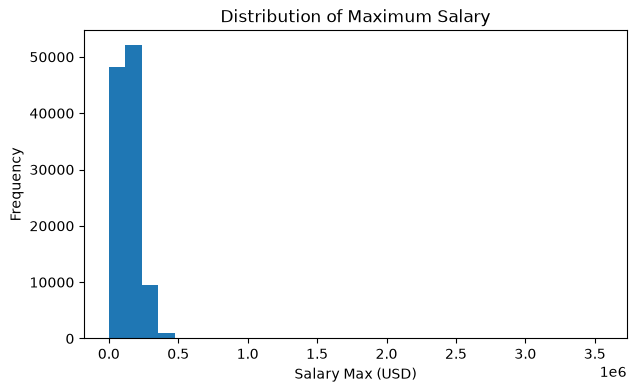

In [24]:
plt.figure(figsize=(7,4))
plt.hist(df['salary_max_usd'].dropna(), bins=30)
plt.title('Distribution of Maximum Salary')
plt.xlabel('Salary Max (USD)')
plt.ylabel('Frequency')
plt.show()

“The maximum salary distribution is highly right-skewed. Most observations are concentrated below 500,000, with the highest frequency occurring in the lower salary range. A long right tail extends towards right, indicating the presence of a small number of extremely high maximum salary values.”



Minimum Salary: relatively smooth right-skewed distribution
Maximum Salary: much more strongly right-skewed, with extreme high-value observations

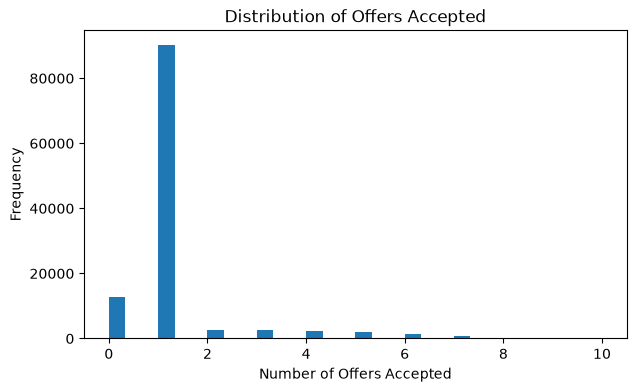

In [30]:
plt.figure(figsize=(7,4))
plt.hist(df['offers_accepted'].dropna(), bins=30)
plt.title('Distribution of Offers Accepted')
plt.xlabel('Number of Offers Accepted')
plt.ylabel('Frequency')
plt.show()

“The distribution of accepted offers is highly concentrated around 0 and 1. Most observations have exactly one accepted offer, while a significant number have no accepted offers. Cases with two or more accepted offers are relatively rare.”

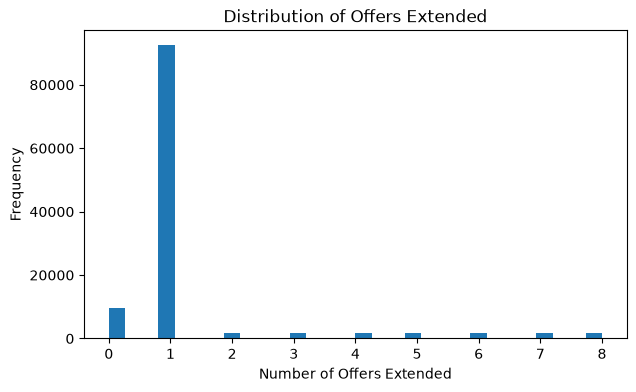

In [29]:
plt.figure(figsize=(7,4))
plt.hist(df['offers_extended'].dropna(), bins=30)
plt.title('Distribution of Offers Extended')
plt.xlabel('Number of Offers Extended')
plt.ylabel('Frequency')
plt.show()

“The distribution of offers extended is highly concentrated around 0 and 1. One extended offer is the most common outcome, while a smaller number of observations have no extended offers. Cases with two or more extended offers are relatively rare.”

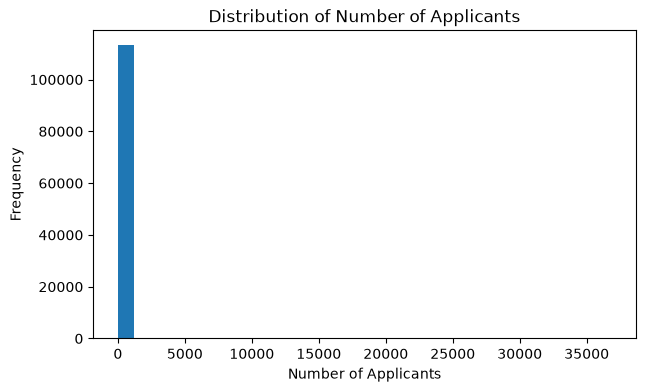

In [33]:
plt.figure(figsize=(7,4))
plt.hist(df['number_of_applicants'].dropna(), bins=30)
plt.title('Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Frequency')
plt.show()

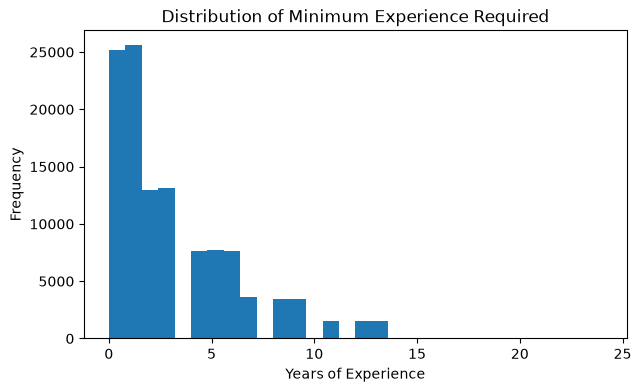

In [34]:
plt.figure(figsize=(7,4))
plt.hist(df['years_experience_min'].dropna(), bins=30)
plt.title('Distribution of Minimum Experience Required')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

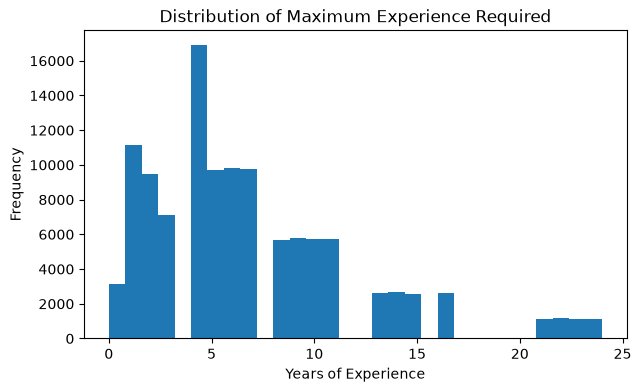

In [35]:
plt.figure(figsize=(7,4))
plt.hist(df['years_experience_max'].dropna(), bins=30)
plt.title('Distribution of Maximum Experience Required')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()